In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Pulse Radar SAR Imaging: Strip-Map SAR via Back-Projection

**Synthetic Aperture Radar (SAR)** is a coherent imaging technique that exploits the motion of a radar platform to synthesise a large virtual aperture. By recording the complex (amplitude + phase) return of each transmitted pulse and combining them coherently during post-processing, SAR achieves **fine azimuth resolution** independent of range and antenna size — a key advantage over real-beam radars.

This notebook demonstrates a full **strip-map SAR** simulation using [RadarSimPy](https://radarsimx.com), from waveform design through to a focused image produced by the **Back-Projection Algorithm (BPA)**.

## Key Concepts

| Quantity | Formula | This example |
|---|---|---|
| Range resolution | $\\Delta R = c/(2B)$ | 5 m (B = 30 MHz) |
| SAR azimuth resolution | $\\Delta_{az} = D_a/2$ | 0.5 m ($D_a$ = 1 m antenna) |
| Synthetic aperture length | $L_s = v \\cdot T_{ap}$ | 12 m (v = 100 m/s, 60 pulses) |
| Back-Projection kernel | $I(x_p,y_p)=\\sum_n s_n\\!\\left(2R_n/c\\right)e^{j4\\pi R_n/\\lambda}$ | Per-pixel coherent sum |

> **Range resolution** $\\Delta R = c/(2B)$ is set by the pulse bandwidth $B$. A wider bandwidth compresses the pulse into a shorter effective duration after matched filtering, yielding finer range discrimination.
>
> **Azimuth resolution** $\\Delta_{az} = D_a/2$ is determined by the real antenna length $D_a$: a *shorter* physical antenna produces a *wider* beam and therefore a *longer* synthetic aperture, paradoxically improving azimuth resolution.

**Scene**: 3 point targets at broadside, X-band (10 GHz), 1 km standoff range, platform speed 100 m/s.

## Workflow

```
Waveform design → Transmitter / Receiver → Scene & Trajectory → sim_radar()
    → Matched Filter (range compression) → Back-Projection (azimuth focus) → SAR image
```

## Setup

In [2]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
from scipy import constants
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

In [3]:
c = constants.c  # Speed of light (m/s)

# Carrier / waveform
fc = 10e9  # Carrier frequency (Hz)
lam = c / fc  # Wavelength (m)
B = 30e6  # Pulse bandwidth (Hz)  →  ΔR = c/(2B) ≈ 5 m
pulse_width = 1 / B  # Rectangular pulse width (s)
prf = 500  # Pulse repetition frequency (Hz)
prp = 1 / prf  # Pulse repetition period (s)
fs = 2 * B  # ADC sample rate (Hz)
tx_power_dbm = 40  # Transmit power (dBm)
num_pulses = 60  # Number of pulses

# Platform / geometry
v_platform = 100.0  # Along-track velocity (m/s)
r0 = 1000.0  # Broadside standoff range (m)

# Derived quantities
range_res = c / (2 * B)
az_res_sar = 0.5  # = D_a/2  (D_a = 1 m antenna)
max_range = c / (2 * prf)
samples_per_pulse = int(prp * fs)
aperture_time = num_pulses / prf
synthetic_aperture = v_platform * aperture_time

print(f"fc={fc/1e9:.0f} GHz  B={B/1e6:.0f} MHz  PRF={prf} Hz  N={num_pulses} pulses")
print(
    f"ΔR={range_res:.1f} m  Δaz={az_res_sar:.2f} m  aperture={synthetic_aperture:.1f} m"
)

fc=10 GHz  B=30 MHz  PRF=500 Hz  N=60 pulses
ΔR=5.0 m  Δaz=0.50 m  aperture=12.0 m


### Transmitter, Receiver & Radar Object

A **rectangular pulse** of width $\\tau = 1/B$ is defined by setting the amplitude modulation arrays `amp` and `mod_t` so that the transmitter is ON only during the first $\\tau$ seconds of each PRI (Pulse Repetition Interval).

**Antenna patterns** are modelled as raised-cosine tapers:

| Axis | Taper | Approx. −3 dB Beamwidth |
|------|-------|-------------------------|
| Azimuth | $\\cos^{20}(\\theta)$ | ≈ 12° |
| Elevation | $\\cos^{60}(\\phi)$ | ≈ 8° |

The receiver is **co-located** with the transmitter (monostatic SAR) and samples at $f_s = 2B = 60\\text{ MHz}$ (Nyquist for the baseband bandwidth). Because each range bin spans $c/(2 f_s) = 2.5\\text{ m}$, the 5 m range resolution occupies 2 samples.

> **Duty cycle** is intentionally kept very low (≈ 0%) so that the simulated rectangular pulse occupies only the first few samples of a 7.2 M-sample PRI waveform. In a real system, a much shorter $\\tau$ relative to PRI would be used to avoid range eclipsing.

In [4]:
# ── Antenna pattern ────────────────────────────────────────────────────────────
antenna_gain = 20  # dBi — moderate gain directional antenna

# Azimuth: cos^20 taper  → ~12° beamwidth @ −3 dB (strip-map illumination)
az_angle = np.arange(-60, 61, 1)
az_pattern = 20 * np.log10(np.abs(np.cos(az_angle / 180 * np.pi)) ** 20) + antenna_gain

# Elevation: cos^60 taper → ~8° beamwidth @ −3 dB
el_angle = np.arange(-30, 31, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 60) + antenna_gain

# ── Pulse envelope (rectangular) ─────────────────────────────────────────────
total_samples = int(prp * num_pulses * fs)
mod_t = np.arange(0, total_samples) / fs
amp = np.zeros(total_samples)
amp[mod_t <= pulse_width] = 1.0  # rectangular pulse ON for first pulse_width seconds

# ── TX channel ────────────────────────────────────────────────────────────────
tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
    amp=amp,
    mod_t=mod_t,
)

tx = Transmitter(
    f=fc,
    t=prp,
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Pulse envelope samples : {int(np.sum(amp > 0))} / {total_samples}")
print(f"  Duty cycle             : {np.sum(amp > 0) / total_samples * 100:.3f}%")

Transmitter configured.
  Pulse envelope samples : 3 / 7200000
  Duty cycle             : 0.000%


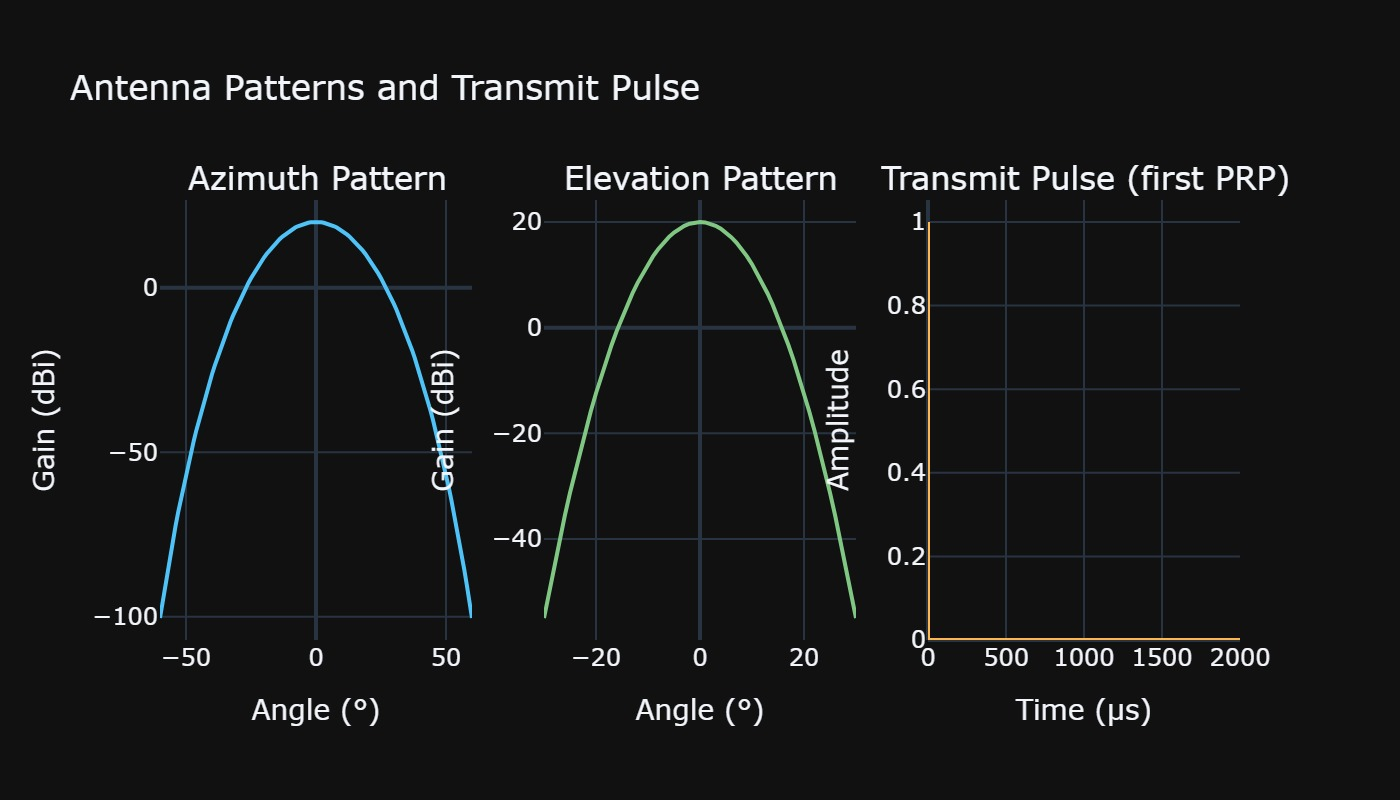

In [5]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Azimuth Pattern",
        "Elevation Pattern",
        "Transmit Pulse (first PRP)",
    ),
)

fig.add_trace(
    go.Scatter(
        x=az_angle, y=az_pattern, name="Azimuth", line=dict(color="#4FC3F7", width=2)
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=el_angle, y=el_pattern, name="Elevation", line=dict(color="#81C784", width=2)
    ),
    row=1,
    col=2,
)

t_us = mod_t[:samples_per_pulse] * 1e6  # µs
fig.add_trace(
    go.Scatter(
        x=t_us,
        y=amp[:samples_per_pulse],
        name="Amplitude",
        line=dict(color="#FFB74D", width=2),
        fill="tozeroy",
    ),
    row=1,
    col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Amplitude", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and Transmit Pulse",
    template="plotly_dark",
    height=400,
    showlegend=False,
)
show(fig)

In [6]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,  # NF = 5 dB
    rf_gain=20,  # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate    : {fs/1e6:.0f} MHz")
print(f"  Samples/pulse  : {samples_per_pulse}")

Receiver configured.
  Sample rate    : 60 MHz
  Samples/pulse  : 120000


### Platform Trajectory & Scene

The radar platform flies in a **straight, level trajectory** along the +x axis at constant velocity $v = 100\\text{ m/s}$, passing broadside (closest approach) to the scene at $x = 0$.

Three **point scatterers** are placed in the scene to test both range and azimuth resolving power:

| Target | Along-track x (m) | Cross-track y (m) | RCS (dBsm) | Purpose |
|--------|--------------------|-------------------|------------|------------------------|
| A | 0 | 1000 | 10 | Bright reference at broadside |
| B | +20 | 1000 | 5 | Tests **azimuth** separation (same range) |
| C | +5 | 1020 | 0 | Tests **range** separation (displaced 20 m) |

Targets A and B are at the same range (1000 m) but separated by 20 m in azimuth — well beyond the 0.5 m SAR azimuth resolution, so they should be clearly resolved. Targets A and C differ by 20 m in range, four times the 5 m range resolution.

> The **phase history** of each target traces a hyperbolic arc in the (pulse, range-sample) space as the platform moves. Back-Projection corrects this range walk and Doppler history to coherently focus each target to a single cell in the image.

In [7]:
# Platform flies along +x; aperture centred at x = 0
pulse_times = np.arange(num_pulses) * prp
pulse_times -= pulse_times.mean()
platform_x = v_platform * pulse_times  # along-track positions (m)

In [8]:
# location: (num_pulses, 3) — one [x, y, z] position per frame
# locations = np.column_stack([
#     platform_x,
#     np.zeros(num_pulses),   # no cross-track offset
#     np.zeros(num_pulses),   # altitude 0 (2-D geometry)
# ])

radar = Radar(
    transmitter=tx,
    receiver=rx,
    # rotation=[90, 0, 0],
    # location=locations,      # (num_pulses, 3)
    # frame_time=pulse_times,  # (num_pulses,) in seconds
)

locations = [radar.time_prop["timestamp"] * v_platform, 0, 0]

radar.set_motion(location=locations, rotation=[90, 0, 0])

print(f"Radar created with {num_pulses} frames (pulses).")

Radar created with 60 frames (pulses).


In [9]:
targets = [
    {"location": (0.0, r0, 0.0), "rcs": 10.0, "phase": 0.0},  # A: centre
    {"location": (20.0, r0, 0.0), "rcs": 5.0, "phase": 0.0},  # B: +20 m az
    {"location": (5.0, r0 + 20, 0.0), "rcs": 0.0, "phase": 0.0},  # C: +20 m range
]

print("Targets:")
for i, t in enumerate(targets):
    x, y, z = t["location"]
    slant = np.hypot(y, x)
    print(
        f"  Target {chr(65+i)}: x={x:+.1f} m, y={y:.0f} m  "
        f"(slant R ≈ {slant:.1f} m)  RCS = {t['rcs']} dBsm"
    )

Targets:
  Target A: x=+0.0 m, y=1000 m  (slant R ≈ 1000.0 m)  RCS = 10.0 dBsm
  Target B: x=+20.0 m, y=1000 m  (slant R ≈ 1000.2 m)  RCS = 5.0 dBsm
  Target C: x=+5.0 m, y=1020 m  (slant R ≈ 1020.0 m)  RCS = 0.0 dBsm


## Simulation & SAR Processing

`sim_radar` propagates the transmitted pulse to each scatterer, applies the two-way path delay, free-space attenuation, and Doppler phase shift for every pulse, and returns the **complex baseband signal** `baseband[rx_channel, pulse_index, sample_index]`.

SAR processing is performed in two stages:

1. **Range Compression (Matched Filter)** — correlates each received pulse with a replica of the transmitted waveform. This step concentrates the pulse energy into a narrow range gate of width $\\Delta R = c/(2B)$, boosting the SNR by a factor equal to the time-bandwidth product $B\\tau$.

2. **Back-Projection Algorithm (BPA)** — for each pixel $(x_p, y_p)$ in the output image, computes the two-way range $R_n = \\|\\mathbf{r}_p - \\mathbf{r}_n\\|$ to the platform at pulse $n$, extracts the range-compressed sample at that range, applies a phase correction $e^{j 4\\pi R_n/\\lambda}$ to align the coherent phases, and sums over all pulses:

$$I(x_p, y_p) = \\sum_{n=0}^{N-1} s_{\\mathrm{mf},n}\\!\\left(\\frac{2R_n}{c}\\right) e^{j4\\pi R_n/\\lambda}$$

> BPA is computationally intensive ($\\mathcal{O}(N \\cdot N_x \\cdot N_y)$) but exact — it handles squint, topography, and non-linear trajectories without approximation, making it the gold standard for high-fidelity SAR image formation.

In [10]:
data = sim_radar(radar, targets, density=1)

baseband = data["baseband"]  # complex I/Q: (rx_ch, pulses, fast-time samples)
timestamp = data["timestamp"]  # time stamps:  (rx_ch, pulses, fast-time samples)

print("Simulation complete.")
print(f"  baseband shape : {baseband.shape}")
print(f"    dim 0 : {baseband.shape[0]} RX channel(s)")
print(f"    dim 1 : {baseband.shape[1]} pulses (synthetic aperture)")
print(f"    dim 2 : {baseband.shape[2]} fast-time samples per pulse")

Simulation complete.
  baseband shape : (1, 60, 120000)
    dim 0 : 1 RX channel(s)
    dim 1 : 60 pulses (synthetic aperture)
    dim 2 : 120000 fast-time samples per pulse


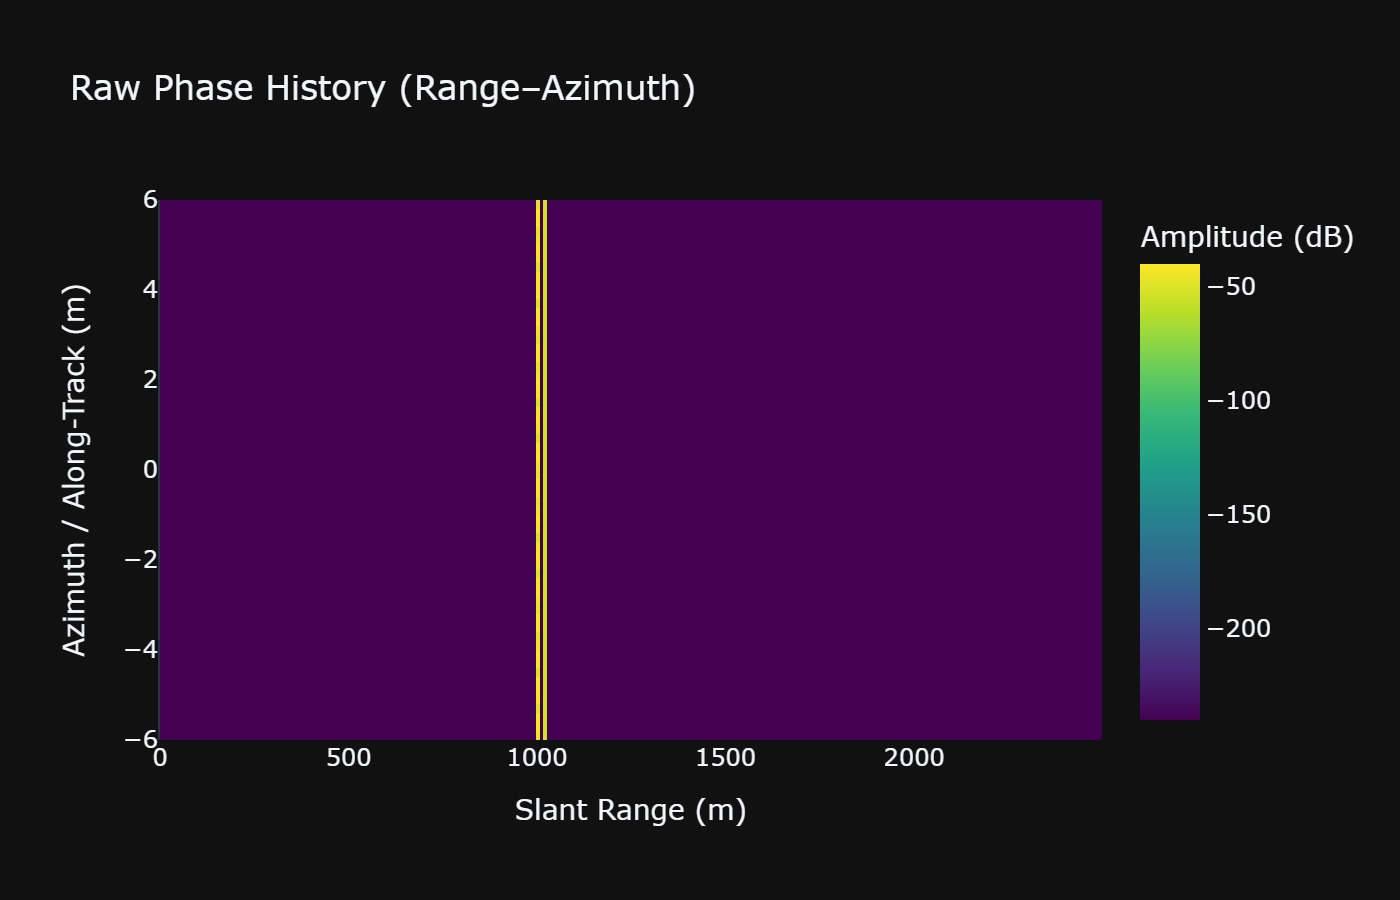

In [11]:
raw = baseband[0, :, :]  # single RX channel: (num_pulses, samples_per_pulse)

# Fast-time → slant range axis
fast_time = np.arange(samples_per_pulse) / fs
slant_range = fast_time * c / 2

az_positions = platform_x  # along-track positions of each pulse

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range,
        y=az_positions,
        z=20 * np.log10(np.abs(baseband[0, :, 0:1000]) + 1e-12),
        colorscale="Viridis",
        colorbar=dict(title="Amplitude (dB)"),
        # zmin=-60, zmax=0,
    )
)
fig.update_layout(
    title="Raw Phase History (Range–Azimuth)",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 1: Range Compression (Matched Filter)

The **matched filter** is the optimal linear filter for maximising the post-filter SNR when the noise is white and Gaussian. For a rectangular pulse of bandwidth $B$, the matched filter is simply a replica of the transmitted pulse (a rectangular gate in the time domain, or equivalently a $\\operatorname{sinc}$-shaped spectrum).

In practice the filter is applied via **frequency-domain multiplication**:

$$S_{\\mathrm{mf}}(f) = S_{\\mathrm{rx}}(f) \\cdot H^*(f), \\quad H(f) = \\operatorname{rect}\\!\\left(\\frac{f}{B}\\right)$$

The output pulse width contracts from $\\tau$ to approximately $1/B$, yielding a **range resolution of $\\Delta R = c/(2B)$**. The processing gain is $B\\tau$ (≈ 1 for a pure rectangular pulse, but in chirp SAR this factor can be $10^4$ or more).

The plot below shows the amplitude of the matched-filter output for one representative pulse.

In [12]:
# ── Matched filter (replica correlation) ─────────────────────────────────────
pulse_samples = int(np.ceil(pulse_width * fs))
replica = np.zeros(samples_per_pulse, dtype=complex)
replica[:pulse_samples] = 1.0  # rectangular pulse replica

# Convolve each pulse with the conjugate-time-reversed replica via FFT
NFFT = samples_per_pulse
REPLICA_FFT = np.fft.fft(np.conj(replica[::-1]), NFFT)

raw_mf = np.zeros_like(raw)
for i in range(num_pulses):
    raw_mf[i] = np.fft.ifft(np.fft.fft(raw[i], NFFT) * REPLICA_FFT)

print(f"Range matched filtering complete.  Shape: {raw_mf.shape}")
print(f"  Range resolution after MF : {range_res:.2f} m  (c / 2B)")

Range matched filtering complete.  Shape: (60, 120000)
  Range resolution after MF : 5.00 m  (c / 2B)


### Step 2: Range-Compressed Phase History

Stacking the matched-filter output of all pulses produces the **phase history** (or *range-Doppler raw data*) matrix. After range compression:

- Each target appears as a **bright spot at a fixed range bin** (the pulse width has been compressed to $\\Delta R = c/(2B)$).
- As the platform moves, the instantaneous range to each target follows a **hyperbolic trajectory** $R_n(x) = \\sqrt{R_0^2 + (x - x_t)^2}$, creating the characteristic curved arcs visible in the phase history.
- The curvature of the arc is inversely proportional to the standoff range $R_0$: closer targets have more pronounced range walk.

These hyperbolic trajectories encode the Doppler history of each scatterer. The subsequent back-projection step flattens them into a focused 2-D image by applying per-pixel phase corrections.

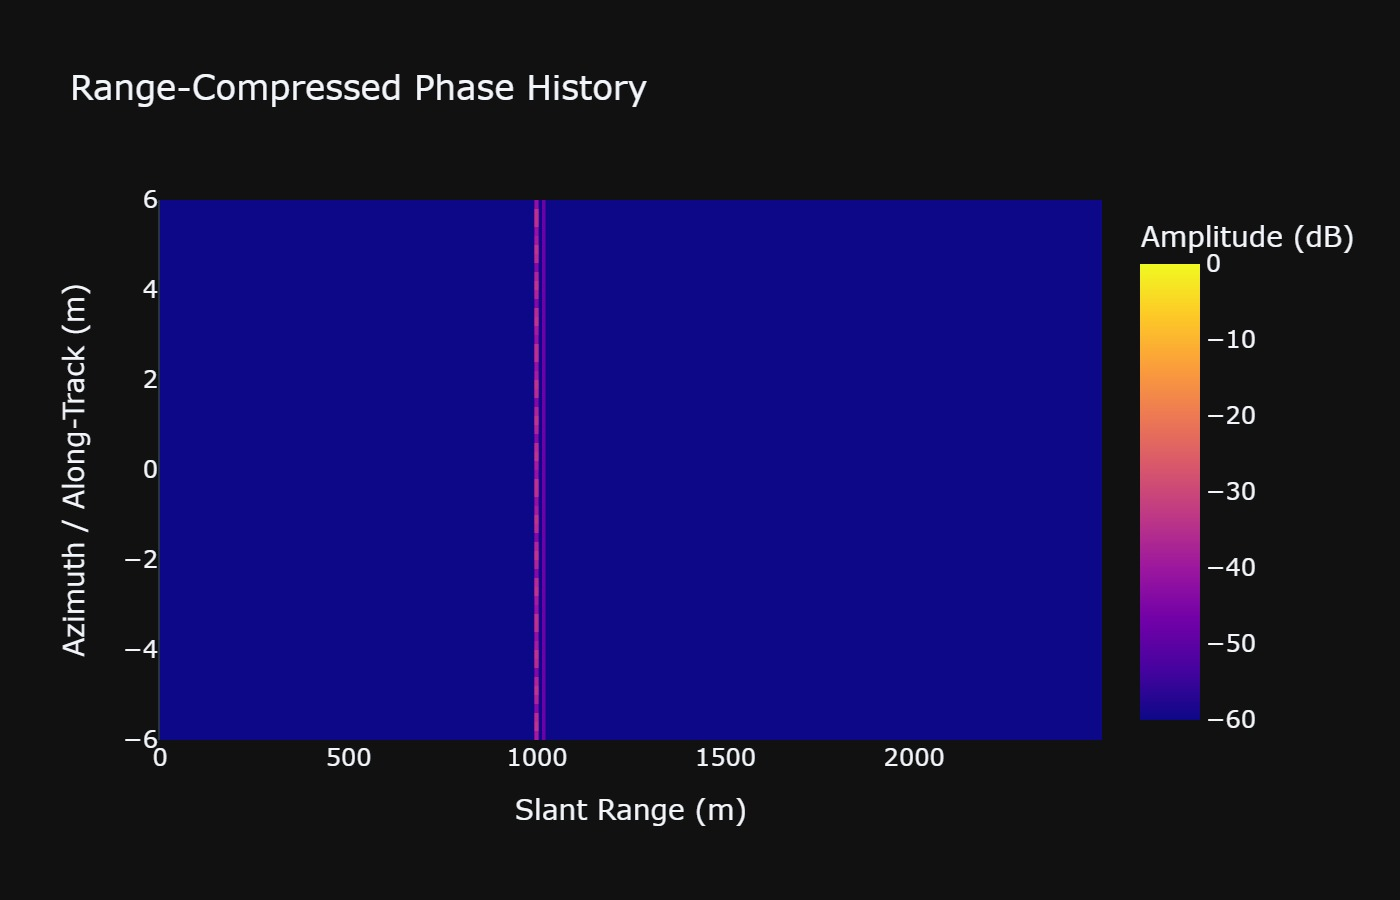

In [13]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range,
        y=az_positions,
        z=20 * np.log10(np.abs(raw_mf[:, 0:1000]) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-60,
        zmax=0,
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark",
    height=450,
)
show(fig)

### Step 3: Back-Projection Focusing

The **Back-Projection Algorithm (BPA)** forms the focused image by coherently summing the range-compressed returns across all pulses, with each sample phase-corrected to the exact two-way range for that pixel–pulse pair.

**Implementation details used here:**

| Parameter | Value | Rationale |
|-----------|-------|----------|
| Image grid spacing | $\\Delta_{az}/2$, $\\Delta R/2$ | 2× oversampling prevents aliasing in the image |
| Aperture weighting | Hanning window | Suppresses sidelobes at the cost of ~1.4× resolution broadening |
| Range interpolation | Linear (nearest-sample) | Fast; fine grid spacing limits interpolation error |

The Hanning window $w_n = 0.5(1 - \\cos(2\\pi n / (N-1)))$ applied across the synthetic aperture trades peak sidelobe level (from −13 dB for a rectangular window down to −32 dB) against a modest 40% broadening of the main lobe.

> **Computational note**: For this example (60 pulses × 200×200 image grid) the BPA runs in seconds on a modern CPU. For spaceborne SAR with thousands of pulses and megapixel images, frequency-domain algorithms (ω-k, SPECAN, CS) or GPU acceleration are typically employed.

In [14]:
# ── Image grid ────────────────────────────────────────────────────────────────
range_window = 60  # ±60 m around r0
range_step = range_res / 2  # 2× oversampled
img_ranges = np.arange(r0 - range_window, r0 + range_window + range_step, range_step)

az_window = 40  # ±40 m
az_step = az_res_sar / 2  # 2× oversampled
img_az = np.arange(-az_window, az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az × {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(
    f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_step:.2f} m)"
)

# ── Aperture tapering window ───────────────────────────────────────────────────
az_taper = np.hanning(num_pulses)  # −43 dB first sidelobe
# az_taper = np.hamming(num_pulses) # −43 dB, slightly wider main lobe
# az_taper = scipy.signal.windows.taylor(num_pulses, nbar=4, sll=35)  # −35 dB Taylor
# ── Back-projection ────────────────────────────────────────────────────────────
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
sample_coords = np.arange(samples_per_pulse)
for pulse_idx in range(num_pulses):
    x_n = platform_x[pulse_idx]
    w_n = az_taper[pulse_idx]  # ← aperture weight for this pulse
    dx = img_az[np.newaxis, :] - x_n
    dy = img_ranges[:, np.newaxis]
    R_n = np.sqrt(dx**2 + dy**2)
    sample_idx = 2.0 * R_n / c * fs
    valid = (sample_idx >= 0) & (sample_idx < samples_per_pulse - 1)
    si_flat = sample_idx.ravel()
    pulse_signal = raw_mf[pulse_idx]
    interp_re = np.interp(
        si_flat, sample_coords, pulse_signal.real, left=0.0, right=0.0
    )
    interp_im = np.interp(
        si_flat, sample_coords, pulse_signal.imag, left=0.0, right=0.0
    )
    interp_sig = (interp_re + 1j * interp_im).reshape(R_n.shape)
    interp_sig[~valid] = 0.0
    phase_corr = np.exp(-1j * 4.0 * np.pi * R_n / lam)
    sar_image += w_n * (interp_sig * phase_corr).T  # ← weighted accumulation

print("Back-projection complete.")
print(f"  SAR image shape : {sar_image.shape}  (Naz × Nr)")

Image grid: 321 az × 50 range pixels
  Azimuth : -40.0 to 40.0 m  (step 0.25 m)
  Range   : 940.0 to 1062.4 m  (step 2.50 m)
Back-projection complete.
  SAR image shape : (321, 50)  (Naz × Nr)


## Results: Focused SAR Image

The focused image is displayed as **normalised power in dB** relative to the peak pixel. Key features to look for:

- All three point targets should appear as **bright spots** at their correct (x, y) positions.
- The **main lobe** of each target response has width ≈ $\\Delta_{az} \\times 1.4 = 0.7\\text{ m}$ in azimuth (Hanning-broadened) and ≈ $\\Delta R \\times 1.4 = 7\\text{ m}$ in range.
- Targets A and B (separated 20 m in azimuth, same range) and targets A and C (separated 20 m in range) should be **clearly resolved** since both separations far exceed the resolution cell size.
- Faint **sidelobes** may be visible around each target at levels ≲ −32 dB below the peak, characteristic of the Hanning aperture window.

The dynamic range of the display is clipped to −40 dB so that weak sidelobes are visible without obscuring the noise floor.

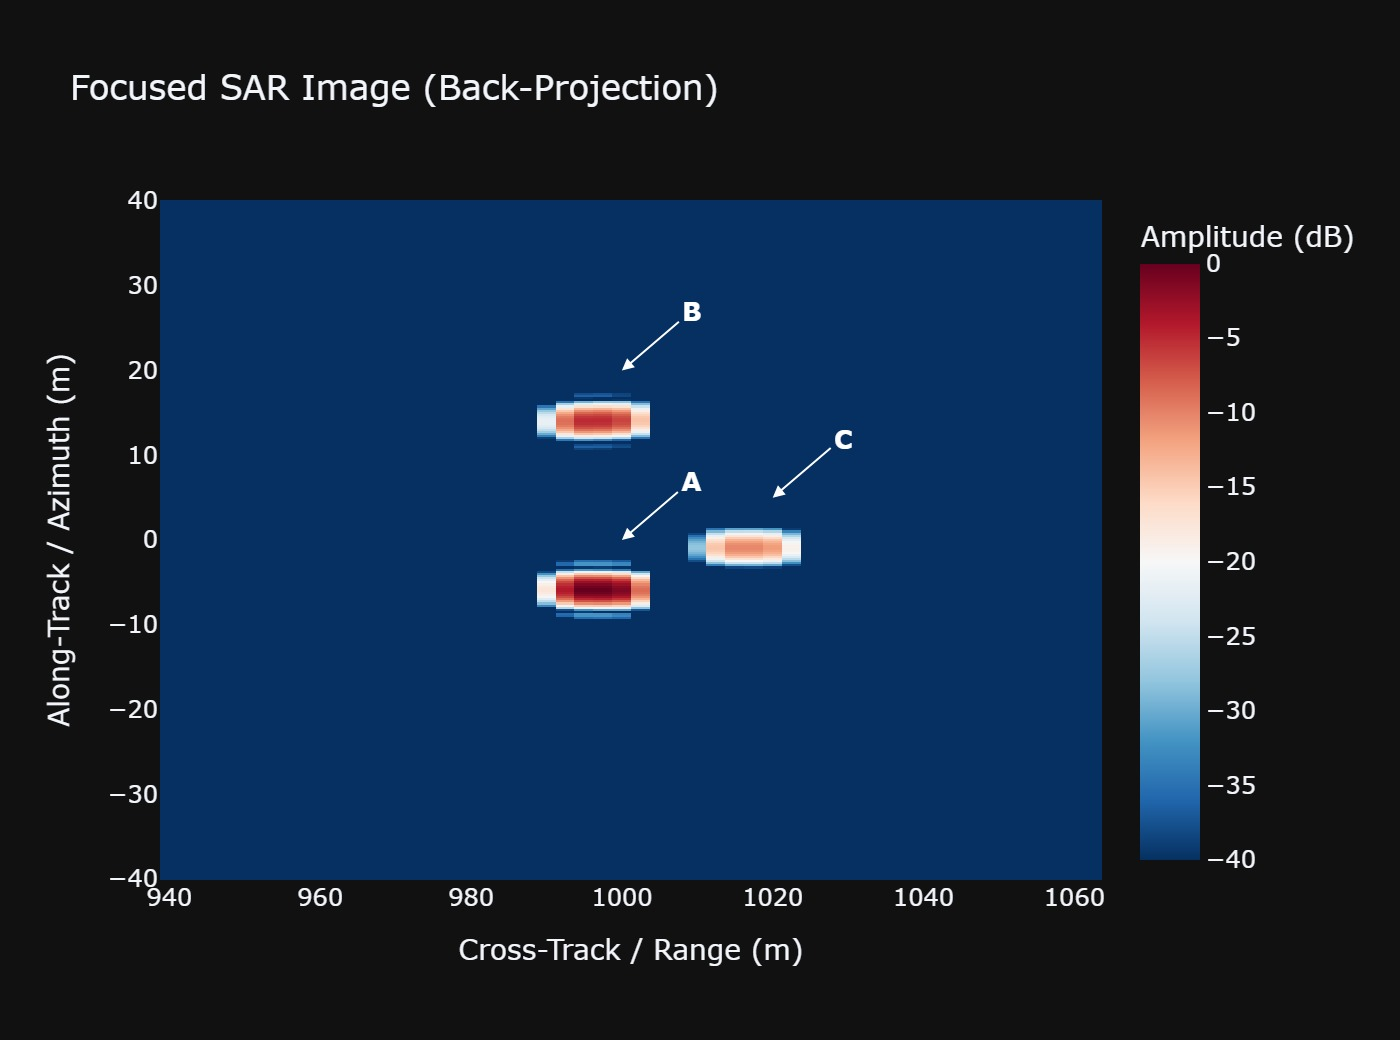

In [15]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()  # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges,
        y=img_az,
        z=sar_amp_db,
        colorscale="RdBu_r",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-40,
        zmax=0,
    )
)

# Annotate ground-truth target positions
for tgt, lbl in zip(targets, ["A", "B", "C"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_annotation(
        x=y_t,
        y=x_t,
        text=f"<b>{lbl}</b>",
        showarrow=True,
        arrowhead=2,
        arrowcolor="white",
        font=dict(color="white", size=13),
        arrowsize=1.2,
        ax=35,
        ay=-30,
    )

fig.update_layout(
    title="Focused SAR Image (Back-Projection)",
    xaxis_title="Cross-Track / Range (m)",
    yaxis_title="Along-Track / Azimuth (m)",
    template="plotly_dark",
    height=520,
)
show(fig)

## Summary

This notebook demonstrated a complete **X-band strip-map SAR simulation** using `RadarSimPy`, covering every stage of the processing chain:

| Stage | Key Parameters | Result |
|---|---|---|
| Waveform design | $f_c$ = 10 GHz, B = 30 MHz, PRF = 500 Hz, $\\tau = 1/B$ | Rectangular pulse, $\\Delta R$ = 5 m |
| Radar hardware | 1 m antenna, cos²⁰/cos⁶⁰ patterns, 40 dBm TX | Monostatic, $f_s = 2B$ |
| Platform / scene | v = 100 m/s, 60 pulses, 3 point targets | Aperture ≈ 12 m |
| Range compression | Matched filter (FFT-based) | $\\Delta R$ = 5 m, pulse compressed |
| Image formation | Back-Projection + Hanning window | $\\Delta_{az}$ ≈ 0.7 m (windowed), all targets focused |

### Further Reading

- Cumming & Wong, *Digital Processing of Synthetic Aperture Radar Data*, Artech House (2005)
- Richards, Scheer & Holm, *Principles of Modern Radar, Vol. I*, SciTech (2010)
- [RadarSimPy documentation](https://radarsimx.com/api/radarsimpy/)

### Possible Extensions

- Replace the rectangular pulse with a **Linear Frequency Modulated (LFM) chirp** to increase the time-bandwidth product and thus processing gain.
- Add **thermal noise** to assess image SNR vs. transmit power.
- Implement **ω-k (wavenumber domain) focusing** and compare speed and image quality against BPA.
- Extend to a **spotlight SAR** mode by steering the antenna beam to track a fixed scene patch.